# Movie Popularity Prediction

Predict the `popularity` score of movies using regression models.

Pipeline: Load & Clean -> Feature Engineering -> Encoding -> Imputation -> Feature Selection -> Models -> Comparison

## 1. Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("train_data.csv", low_memory=False).copy()
print("Loaded:", df.shape)
print("\nTarget (popularity) stats:")
print(df["popularity"].describe().round(3))
print(f"Skewness: {df['popularity'].skew():.2f}")

Loaded: (1048575, 39)

Target (popularity) stats:
count    1048575.000
mean           1.266
std            7.373
min            0.000
25%            0.600
50%            0.600
75%            0.915
max         2994.357
Name: popularity, dtype: float64
Skewness: 180.15


## 2. Pre-Split Cleaning

In [2]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["theatrical"] = df["theatrical"].astype(int)
df["adult"] = (
    df["adult"].map({"False": 0, "True": 1, False: 0, True: 1}).fillna(0).astype(int)
)

df["revenue"] = df["revenue"].clip(lower=0)
df["budget"] = df["budget"].clip(lower=0)
# runtime = 0 means unknown, not a real zero-minute film
df["runtime"] = df["runtime"].clip(lower=0).replace(0, np.nan)

# cinema was invented ~1888; anything beyond 2026 is a data-entry error
df["release_date"] = df["release_date"].where(
    df["release_date"].between("1888-01-01", "2026-12-31"), other=pd.NaT
)

# popularity has extreme skew (skew ~180); clip at 99.5th percentile so models
# learn the general distribution rather than chasing a handful of outliers
pop_cap = df["popularity"].quantile(0.995)
df["popularity"] = df["popularity"].clip(upper=pop_cap)
print(f"Popularity capped at 99.5th pct: {pop_cap:.2f}")
print(f"New skew after cap: {df['popularity'].skew():.2f}")

sentiment_map = {"positive": 1, "neutral": 0, "negative": -1}
if "movie_sentiment" in df.columns:
    df["sentiment_encoded"] = df["movie_sentiment"].map(sentiment_map).fillna(0)

text_cols = [
    "title",
    "original_title",
    "overview",
    "tagline",
    "backdrop_path",
    "homepage",
    "imdb_id",
    "poster_path",
]
for c in text_cols:
    df[c] = df[c].fillna("Unknown" if c in ("title", "original_title") else "")

list_cols = [
    "genres",
    "production_companies",
    "production_countries",
    "spoken_languages",
]
for c in list_cols:
    df[c] = df[c].fillna("")

print("\nPre-split cleaning done. Shape:", df.shape)

Duplicates removed: 159
Popularity capped at 99.5th pct: 18.75
New skew after cap: 5.80

Pre-split cleaning done. Shape: (1048416, 39)


## 3. Train / Test Split

In [3]:
# Split before feature engineering to prevent data leakage
TARGET = "popularity"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train mean: {y_train.mean():.3f}  |  y_test mean: {y_test.mean():.3f}")

X_train: (838732, 38)  |  X_test: (209684, 38)
y_train mean: 1.140  |  y_test mean: 1.142


## 4. Feature Engineering

In [4]:
for df_fe in [X_train, X_test]:

    # date features
    df_fe["release_year"] = df_fe["release_date"].dt.year
    df_fe["release_month"] = df_fe["release_date"].dt.month
    df_fe["release_quarter"] = df_fe["release_date"].dt.quarter
    df_fe["is_summer"] = df_fe["release_month"].isin([6, 7, 8]).astype(int)
    df_fe["is_holiday"] = df_fe["release_month"].isin([11, 12]).astype(int)
    df_fe["movie_age"] = (2025 - df_fe["release_year"]).clip(lower=0)
    df_fe["is_recent"] = (df_fe["release_year"] >= 2015).astype(int)

    # metadata presence flags (well-produced movies tend to have these)
    df_fe["has_overview"] = (df_fe["overview"].str.strip() != "").astype(int)
    df_fe["has_tagline"] = (df_fe["tagline"].str.strip() != "").astype(int)
    df_fe["has_homepage"] = (df_fe["homepage"].str.strip() != "").astype(int)
    df_fe["has_poster"] = (df_fe["poster_path"].str.strip() != "").astype(int)
    df_fe["has_backdrop"] = (df_fe["backdrop_path"].str.strip() != "").astype(int)
    df_fe["has_imdb"] = (df_fe["imdb_id"].str.strip() != "").astype(int)

    # ~94% of budget values are 0 (unknown), so the flag is more useful than the raw value
    df_fe["has_budget"] = (df_fe["budget"] > 0).astype(int)
    df_fe["has_revenue"] = (df_fe["revenue"] > 0).astype(int)

    # log-transform to compress right-skewed distributions
    df_fe["log_vote_count"] = np.log1p(df_fe["vote_count"])
    df_fe["log_budget"] = np.log1p(df_fe["budget"])
    df_fe["log_revenue"] = np.log1p(df_fe["revenue"])

    df_fe["profit"] = (df_fe["revenue"] - df_fe["budget"]).clip(lower=0)
    df_fe["log_profit"] = np.log1p(df_fe["profit"])
    df_fe["has_profit"] = (df_fe["profit"] > 0).astype(int)

    # genres are comma-separated plain strings, e.g. "Action, Science Fiction"
    df_fe["genre_count"] = df_fe["genres"].apply(
        lambda x: len([g for g in str(x).split(",") if g.strip()]) if x else 0
    )

    df_fe["company_count"] = df_fe["production_companies"].apply(
        lambda x: len([c for c in str(x).split(",") if c.strip()]) if x else 0
    )
    df_fe["country_count"] = df_fe["production_countries"].apply(
        lambda x: len([c for c in str(x).split(",") if c.strip()]) if x else 0
    )
    df_fe["is_us_production"] = (
        df_fe["production_countries"]
        .str.contains("United States of America", na=False)
        .astype(int)
    )
    df_fe["is_uk_production"] = (
        df_fe["production_countries"]
        .str.contains("United Kingdom", na=False)
        .astype(int)
    )
    df_fe["is_international"] = (df_fe["country_count"] > 1).astype(int)

    df_fe["spoken_lang_count"] = df_fe["spoken_languages"].apply(
        lambda x: len([l for l in str(x).split(",") if l.strip()]) if x else 0
    )
    df_fe["is_english_lang"] = (
        df_fe["spoken_languages"].str.contains("English", na=False).astype(int)
    )
    df_fe["is_multilingual"] = (df_fe["spoken_lang_count"] > 1).astype(int)

    df_fe["overview_len"] = df_fe["overview"].str.split().str.len().fillna(0)

print("Feature engineering done.")
print("X_train shape:", X_train.shape)

Feature engineering done.
X_train shape: (838732, 69)


## 5. Encoding Categorical Columns

In [5]:
quality_map = {
    "real_confident": 5,
    "real_likely": 4,
    "stub_legitimate": 3,
    "stub_uncertain": 2,
    "spam_likely": 1,
    "spam_confident": 0,
}
X_train["quality_encoded"] = X_train["quality"].map(quality_map)
X_test["quality_encoded"] = X_test["quality"].map(quality_map)

status_map = {
    "Released": 5,
    "Post Production": 4,
    "In Production": 3,
    "Planned": 2,
    "Rumored": 1,
    "Canceled": 0,
}
X_train["status_encoded"] = X_train["status"].map(status_map)
X_test["status_encoded"] = X_test["status"].map(status_map)
fill_status = X_train["status_encoded"].median()
X_train["status_encoded"] = X_train["status_encoded"].fillna(fill_status)
X_test["status_encoded"] = X_test["status_encoded"].fillna(fill_status)

# fit top-language list on train only to avoid leakage, then group rare languages as "other"
top_langs = X_train["original_language"].value_counts().nlargest(15).index.tolist()
X_train["lang_group"] = X_train["original_language"].apply(
    lambda x: x if x in top_langs else "other"
)
X_test["lang_group"] = X_test["original_language"].apply(
    lambda x: x if x in top_langs else "other"
)
lang_tr = pd.get_dummies(X_train["lang_group"], prefix="lang", dtype=int)
lang_te = pd.get_dummies(X_test["lang_group"], prefix="lang", dtype=int)
lang_te = lang_te.reindex(columns=lang_tr.columns, fill_value=0)
X_train = pd.concat([X_train, lang_tr], axis=1)
X_test = pd.concat([X_test, lang_te], axis=1)

all_genres = set()
for val in X_train["genres"].dropna():
    for g in str(val).split(","):
        g = g.strip()
        if g:
            all_genres.add(g)
print(f"Unique genres found: {len(all_genres)} -> {sorted(all_genres)}")

for genre in sorted(all_genres):
    col = "genre_" + genre.lower().replace(" ", "_").replace("-", "_").replace(
        "&", "and"
    )
    X_train[col] = X_train["genres"].str.contains(genre, na=False).astype(int)
    X_test[col] = X_test["genres"].str.contains(genre, na=False).astype(int)

company_counts = Counter()
for val in X_train["production_companies"].dropna():
    for c in str(val).split(","):
        c = c.strip()
        if c:
            company_counts[c] += 1
top_companies = [c for c, _ in company_counts.most_common(20)]

for company in top_companies:
    col = (
        "co_"
        + company.lower().replace(" ", "_").replace("-", "_").replace(".", "")[:25]
    )
    X_train[col] = (
        X_train["production_companies"]
        .str.contains(company, na=False, regex=False)
        .astype(int)
    )
    X_test[col] = (
        X_test["production_companies"]
        .str.contains(company, na=False, regex=False)
        .astype(int)
    )

print("\nEncoding done. X_train shape:", X_train.shape)

Unique genres found: 19 -> ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

Encoding done. X_train shape: (838732, 127)


## 6. Imputation & Outlier Capping

In [6]:
# emotion columns are missing for ~82%+ of movies because those movies have no
# TMDB keywords to score. Missing here means "no signal", not "unknown", so fill with 0.
emotion_cols = [
    "movie_intensity_anger",
    "movie_intensity_anticipation",
    "movie_intensity_disgust",
    "movie_intensity_fear",
    "movie_intensity_joy",
    "movie_intensity_sadness",
    "movie_intensity_surprise",
    "movie_intensity_trust",
    "movie_valence",
    "movie_vad_valence",
    "movie_vad_arousal",
    "movie_vad_dominance",
    "movie_scl_shift",
    "movie_scl_coverage",
]
X_train["has_emotion_data"] = X_train["movie_valence"].notna().astype(int)
X_test["has_emotion_data"] = X_test["movie_valence"].notna().astype(int)

for col in emotion_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna(0)
        X_test[col] = X_test[col].fillna(0)

other_impute = [
    "runtime",
    "release_year",
    "release_month",
    "release_quarter",
    "movie_age",
    "overview_len",
]
other_impute = [
    c for c in other_impute if c in X_train.columns and X_train[c].isnull().any()
]
medians = X_train[other_impute].median()
X_train[other_impute] = X_train[other_impute].fillna(medians)
X_test[other_impute] = X_test[other_impute].fillna(medians)

# use 3x IQR instead of 1.5x because the data is legitimately skewed;
# we only want to remove extreme errors, not clip real variance
cap_params = {}   # save for test script
for col in ["runtime", "vote_average", "overview_len"]:
    if col not in X_train.columns:
        continue
    Q1, Q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    lo, hi = Q1 - 3 * (Q3 - Q1), Q3 + 3 * (Q3 - Q1)
    cap_params[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)
    print(f"Capped {col}: [{lo:.1f}, {hi:.1f}]")

print("\nImputation done.")
print("Nulls in X_train:", int(X_train.isnull().sum().sum()))
print("Nulls in X_test :", int(X_test.isnull().sum().sum()))

Capped runtime: [-168.0, 273.0]
Capped vote_average: [-14.5, 19.3]
Capped overview_len: [-127.0, 188.0]

Imputation done.
Nulls in X_train: 118107
Nulls in X_test : 29873


## 7. Drop Redundant Columns

In [7]:
cols_to_drop = [
    # replaced by encoded or log versions
    "quality",
    "status",
    "original_language",
    "lang_group",
    "budget",
    "revenue",
    "vote_count",
    "profit",
    # replaced by extracted features
    "release_date",
    "genres",
    "production_companies",
    "production_countries",
    "spoken_languages",
    # raw text with no direct numeric value
    "title",
    "original_title",
    "overview",
    "tagline",
    "backdrop_path",
    "homepage",
    "imdb_id",
    "poster_path",
    # near-zero variance and already-encoded columns
    "adult",
    "movie_sentiment",
    "id",
]
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print("Dropped:", len(cols_to_drop), "columns")
print("Final X_train shape:", X_train.shape)
print("Final X_test  shape:", X_test.shape)

Dropped: 23 columns
Final X_train shape: (838732, 105)
Final X_test  shape: (209684, 105)


## 8. Feature Selection

Low-variance columns dropped (32): ['movie_intensity_anger', 'movie_intensity_anticipation', 'movie_intensity_disgust', 'movie_intensity_sadness', 'movie_intensity_surprise', 'movie_scl_shift', 'lang_ar', 'lang_cs', 'lang_nl', 'lang_sv', 'lang_tr', 'genre_western', 'co_warner_bros_pictures', 'co_bbc', 'co_columbia_pictures', 'co_metro_goldwyn_mayer', 'co_arte', 'co_onf_|_nfb', 'co_universal_pictures', 'co_paramount', 'co_toei_company', 'co_zdf', 'co_nikkatsu_corporation', 'co_20th_century_fox', 'co_ard', 'co_mosfilm', 'co_canal+', 'co_toho', 'co_shochiku', 'co_česká_televize', 'co_france_télévisions', 'co_rko_radio_pictures']

Top 20 features by |correlation| with popularity:
log_vote_count        0.7760
log_revenue           0.5562
log_profit            0.4953
has_revenue           0.4693
has_profit            0.4318
quality_encoded       0.4021
company_count         0.4010
log_budget            0.3896
has_backdrop          0.3571
vote_average          0.3473
genre_count           0.3

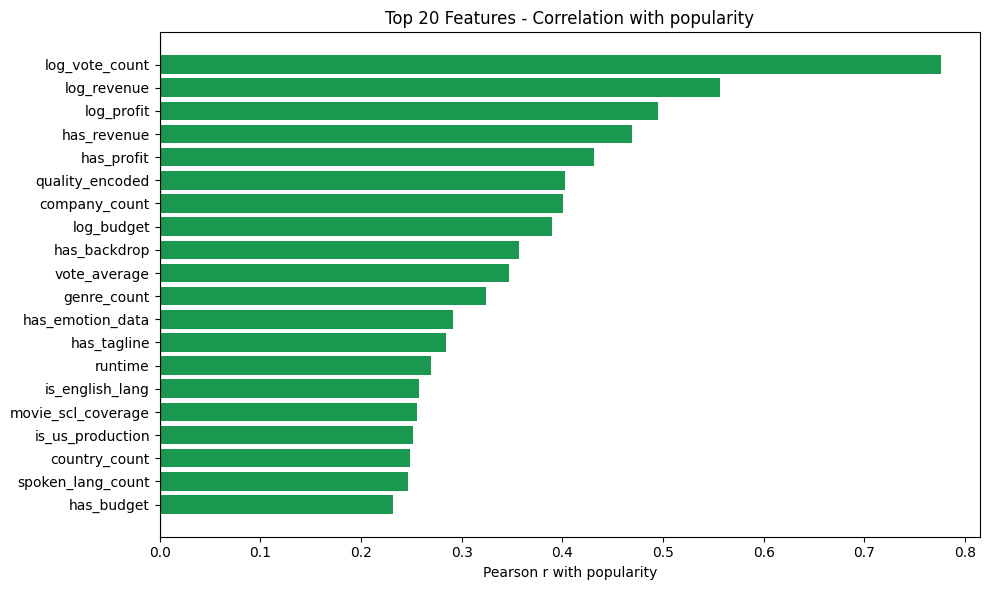

In [8]:
# drop columns where 99%+ of values are identical
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)
keep_mask = selector.get_support()
dropped_low_var = X_train.columns[~keep_mask].tolist()
print(f"Low-variance columns dropped ({len(dropped_low_var)}): {dropped_low_var}")

X_train_v = X_train.loc[:, keep_mask].copy()
X_test_v = X_test.loc[:, keep_mask].copy()

# compute correlations on train only
corr = (
    X_train_v.assign(popularity=y_train.values)
    .corr(numeric_only=True)["popularity"]
    .drop("popularity")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("\nTop 20 features by |correlation| with popularity:")
print(corr.head(20).round(4).to_string())

# tree models use all features; linear models use a curated subset to reduce noise
X_train_tree = X_train_v.copy()
X_test_tree = X_test_v.copy()

linear_core = [
    "log_vote_count",
    "log_budget",
    "log_revenue",
    "log_profit",
    "vote_average",
    "quality_encoded",
    "status_encoded",
    "runtime",
    "has_budget",
    "has_revenue",
    "has_imdb",
    "has_backdrop",
    "has_poster",
    "has_homepage",
    "is_us_production",
    "is_english_lang",
    "is_multilingual",
    "is_recent",
    "is_summer",
    "is_holiday",
    "theatrical",
    "overview_len",
    "has_emotion_data",
    "sentiment_encoded",
    "company_count",
]
linear_core = [c for c in linear_core if c in X_train_v.columns]
X_train_linear = X_train_v[linear_core].copy()
X_test_linear = X_test_v[linear_core].copy()

print(f"\nTree  features : {X_train_tree.shape[1]}")
print(f"Linear features: {X_train_linear.shape[1]}")

top20 = corr.head(20)
plt.figure(figsize=(10, 6))
colors = ["#d73027" if v < 0 else "#1a9850" for v in top20]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson r with popularity")
plt.title("Top 20 Features - Correlation with popularity")
plt.tight_layout()
plt.show()

## 9. Target Transform (Log)

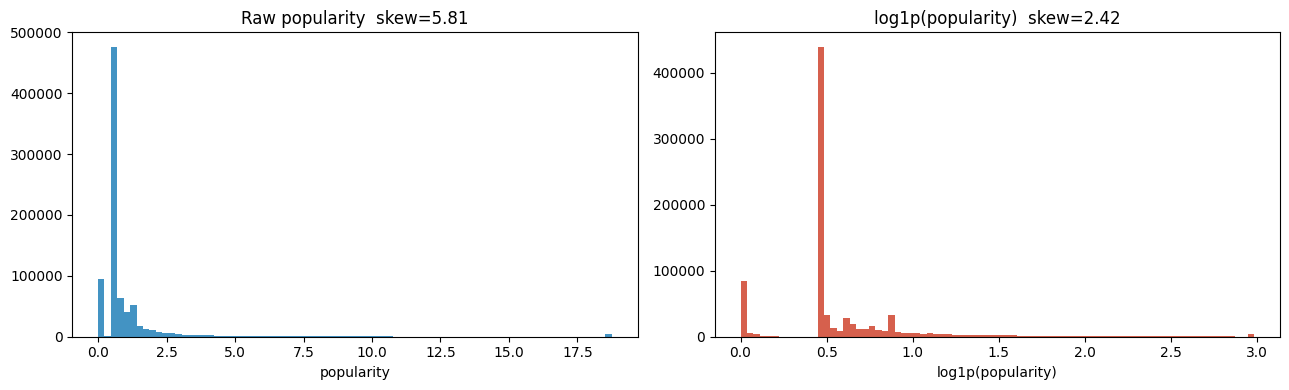

Models train on log target; evaluation is always on original scale.


In [9]:
# log1p makes residuals more Gaussian; predictions are always converted back with expm1()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(y_train, bins=80, color="#4393c3")
ax[0].set_title(f"Raw popularity  skew={y_train.skew():.2f}")
ax[0].set_xlabel("popularity")

y_train_log = np.log1p(y_train.clip(lower=0))
y_test_log = np.log1p(y_test.clip(lower=0))

ax[1].hist(y_train_log, bins=80, color="#d6604d")
ax[1].set_title(f"log1p(popularity)  skew={y_train_log.skew():.2f}")
ax[1].set_xlabel("log1p(popularity)")
plt.tight_layout()
plt.show()
print("Models train on log target; evaluation is always on original scale.")

## 10. Evaluation Helper

In [10]:
results = []


def evaluate(name, model_or_fn, X_tr, X_te, y_tr, y_te, is_log=True):
    """
    Evaluate a model on both train and test sets.
    Handles log-space predictions by converting back with expm1 before scoring.
    Prints R2, MSE, RMSE and a simple overfitting/underfitting diagnosis.
    """
    if callable(model_or_fn):
        pred_tr_raw = model_or_fn(X_tr)
        pred_te_raw = model_or_fn(X_te)
    else:
        pred_tr_raw = model_or_fn.predict(X_tr)
        pred_te_raw = model_or_fn.predict(X_te)

    if is_log:
        pred_tr = np.expm1(pred_tr_raw).clip(0)
        pred_te = np.expm1(pred_te_raw).clip(0)
        y_tr_orig = np.expm1(y_tr).clip(0)
        y_te_orig = np.expm1(y_te).clip(0)
    else:
        pred_tr, pred_te = pred_tr_raw.clip(0), pred_te_raw.clip(0)
        y_tr_orig, y_te_orig = np.asarray(y_tr), np.asarray(y_te)

    mse_tr = mean_squared_error(y_tr_orig, pred_tr)
    rmse_tr = np.sqrt(mse_tr)
    r2_tr = r2_score(y_tr_orig, pred_tr)

    mse_te = mean_squared_error(y_te_orig, pred_te)
    rmse_te = np.sqrt(mse_te)
    r2_te = r2_score(y_te_orig, pred_te)

    results.append(
        {
            "Model": name,
            "Train R2": round(r2_tr, 4),
            "Test R2": round(r2_te, 4),
            "Train RMSE": round(rmse_tr, 4),
            "Test RMSE": round(rmse_te, 4),
            "Train MSE": round(mse_tr, 4),
            "Test MSE": round(mse_te, 4),
        }
    )

    bar = "=" * 58
    print(bar)
    print(f"  {name}")
    print(bar)
    print(f"  {'Metric':<10}  {'TRAIN':>10}  {'TEST':>10}")
    print(f"  {'-'*10}  {'-'*10}  {'-'*10}")
    print(f"  {'R2':<10}  {r2_tr:>10.4f}  {r2_te:>10.4f}")
    print(f"  {'MSE':<10}  {mse_tr:>10.4f}  {mse_te:>10.4f}")
    print(f"  {'RMSE':<10}  {rmse_tr:>10.4f}  {rmse_te:>10.4f}")
    print()

    r2_gap = r2_tr - r2_te
    if r2_tr < 0.30:
        diagnosis = "UNDERFITTING - model too simple, misses the pattern on both sets."
    elif r2_gap > 0.15:
        diagnosis = (
            "OVERFITTING  - train R2 much higher than test R2; model memorised noise."
        )
    elif r2_te >= 0.65:
        diagnosis = "GOOD FIT     - strong performance, train/test are close."
    elif r2_te >= 0.40:
        diagnosis = "FAIR FIT     - decent generalisation for this skewed target."
    else:
        diagnosis = "WEAK FIT     - model explains little variance on unseen data."

    print(f"  Diagnosis : {diagnosis}")
    print(f"  R2 gap (train - test) = {r2_gap:.4f}")
    print()

## 11. Model 1: Linear Regression

  Linear Regression
  Metric           TRAIN        TEST
  ----------  ----------  ----------
  R2              0.6896      0.6897
  MSE             1.3361      1.3431
  RMSE            1.1559      1.1589

  Diagnosis : GOOD FIT     - strong performance, train/test are close.
  R2 gap (train - test) = -0.0001



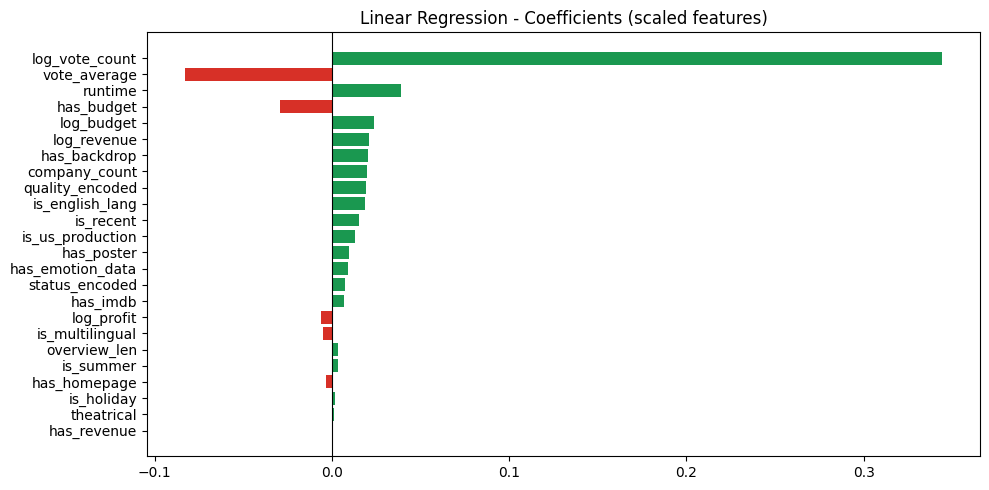

In [11]:
pipeline_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ]
)
pipeline_lr.fit(X_train_linear, y_train_log)

evaluate(
    "Linear Regression",
    pipeline_lr,
    X_train_linear,
    X_test_linear,
    y_train_log,
    y_test_log,
)

coefs = pd.Series(pipeline_lr["lr"].coef_, index=linear_core).sort_values(
    key=abs, ascending=False
)
plt.figure(figsize=(10, 5))
plt.barh(
    coefs.index[::-1],
    coefs.values[::-1],
    color=["#d73027" if v < 0 else "#1a9850" for v in coefs[::-1]],
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression - Coefficients (scaled features)")
plt.tight_layout()
plt.show()

## 12. Model 2: Polynomial Regression (degree=2)

In [12]:
pipeline_poly2 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("lr", LinearRegression()),
    ]
)
pipeline_poly2.fit(X_train_linear, y_train_log)

evaluate(
    "Polynomial Regression (deg=2)",
    pipeline_poly2,
    X_train_linear,
    X_test_linear,
    y_train_log,
    y_test_log,
)

print(
    f"Feature count after deg-2 expansion: {pipeline_poly2['poly'].n_output_features_}"
)

  Polynomial Regression (deg=2)
  Metric           TRAIN        TEST
  ----------  ----------  ----------
  R2              0.7414      0.7428
  MSE             1.1131      1.1132
  RMSE            1.0550      1.0551

  Diagnosis : GOOD FIT     - strong performance, train/test are close.
  R2 gap (train - test) = -0.0014

Feature count after deg-2 expansion: 324


## 13. Model 3: Random Forest

  Random Forest
  Metric           TRAIN        TEST
  ----------  ----------  ----------
  R2              0.8183      0.7975
  MSE             0.7822      0.8765
  RMSE            0.8844      0.9362

  Diagnosis : GOOD FIT     - strong performance, train/test are close.
  R2 gap (train - test) = 0.0208



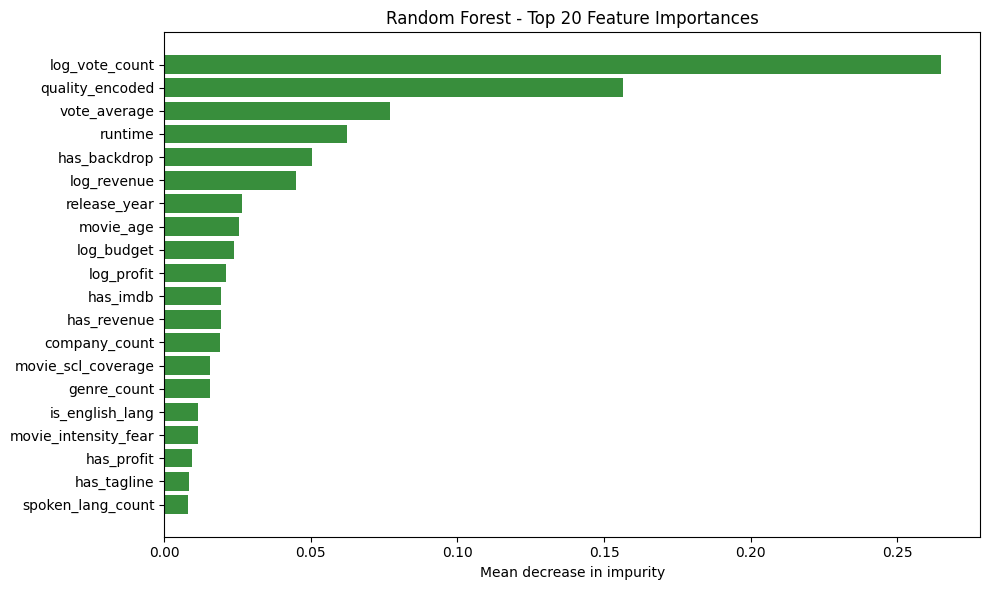

In [13]:
model_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
model_rf.fit(X_train_tree, y_train_log)

evaluate("Random Forest", model_rf, X_train_tree, X_test_tree, y_train_log, y_test_log)

imp = pd.Series(model_rf.feature_importances_, index=X_train_tree.columns)
imp = imp.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
plt.barh(imp.index[::-1], imp.values[::-1], color="#388E3C")
plt.title("Random Forest - Top 20 Feature Importances")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## 14. Model 4: XGBoost

  XGBoost
  Metric           TRAIN        TEST
  ----------  ----------  ----------
  R2              0.8486      0.8432
  MSE             0.6517      0.6785
  RMSE            0.8073      0.8237

  Diagnosis : GOOD FIT     - strong performance, train/test are close.
  R2 gap (train - test) = 0.0054



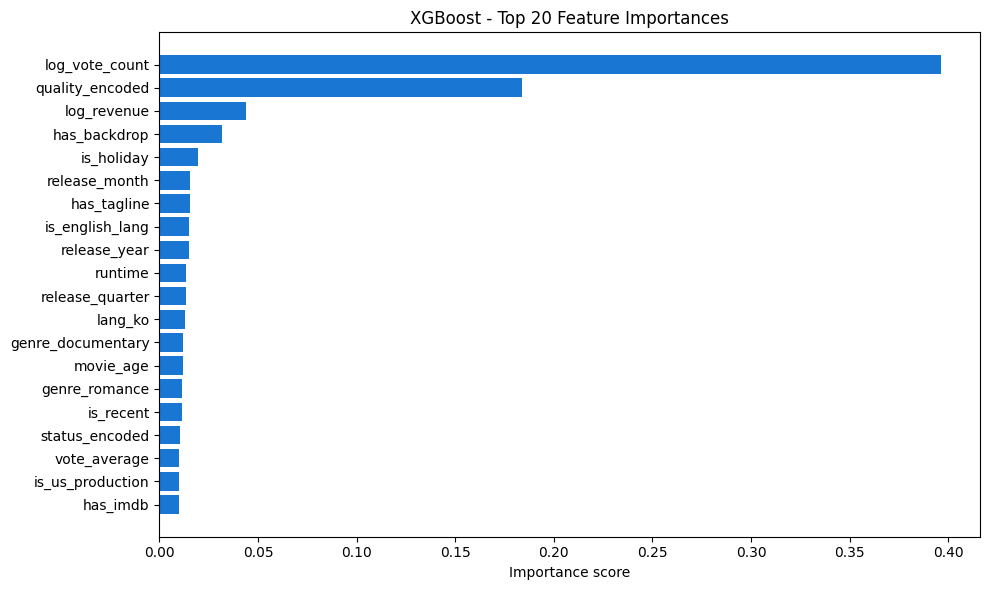

In [14]:
model_xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    verbosity=0,
)
model_xgb.fit(X_train_tree, y_train_log)

evaluate("XGBoost", model_xgb, X_train_tree, X_test_tree, y_train_log, y_test_log)

imp_xgb = pd.Series(model_xgb.feature_importances_, index=X_train_tree.columns)
imp_xgb = imp_xgb.sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 6))
plt.barh(imp_xgb.index[::-1], imp_xgb.values[::-1], color="#1976D2")
plt.title("XGBoost - Top 20 Feature Importances")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

## 15. Final Comparison

  FINAL MODEL COMPARISON


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MSE,Test MSE
0,XGBoost,0.8486,0.8432,0.8073,0.8237,0.6517,0.6785
1,Random Forest,0.8183,0.7975,0.8844,0.9362,0.7822,0.8765
2,Polynomial Regression (deg=2),0.7414,0.7428,1.0550,1.0551,1.1131,1.1132
3,Linear Regression,0.6896,0.6897,1.1559,1.1589,1.3361,1.3431


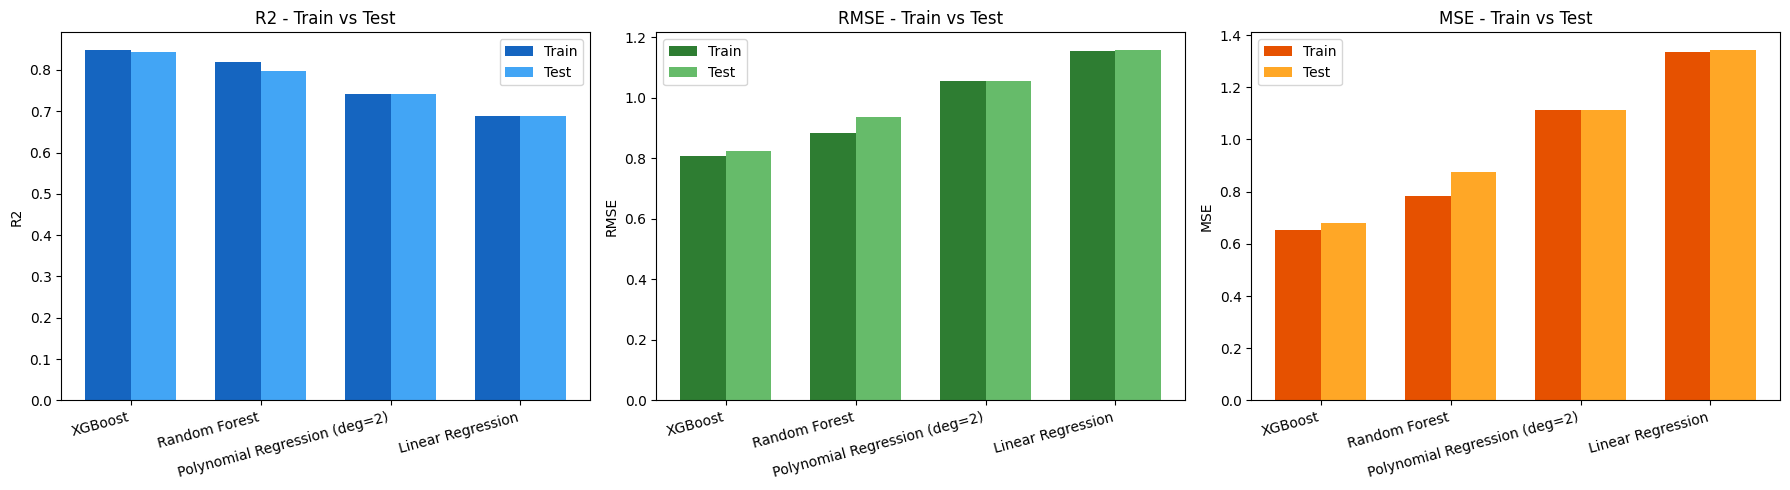


  OVERFITTING / UNDERFITTING SUMMARY
  Model                               Train R2   Test R2       Gap  Status
  -----------------------------------  --------  --------  --------  --------------------
  XGBoost                               0.8486    0.8432    0.0054  Good fit
  Random Forest                         0.8183    0.7975    0.0208  Good fit
  Polynomial Regression (deg=2)         0.7414    0.7428   -0.0014  Good fit
  Linear Regression                     0.6896    0.6897   -0.0001  Good fit

  Best model: XGBoost
     Test R2 = 0.8432  |  Test RMSE = 0.8237


In [15]:
final_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("Test R2", ascending=False)
    .reset_index(drop=True)
)
print("=" * 70)
print("  FINAL MODEL COMPARISON")
print("=" * 70)
display(
    final_df[
        [
            "Model",
            "Train R2",
            "Test R2",
            "Train RMSE",
            "Test RMSE",
            "Train MSE",
            "Test MSE",
        ]
    ]
)

x = np.arange(len(final_df))
width = 0.35
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(x - width / 2, final_df["Train R2"], width, label="Train", color="#1565C0")
axes[0].bar(x + width / 2, final_df["Test R2"], width, label="Test", color="#42A5F5")
axes[0].set_xticks(x)
axes[0].set_xticklabels(final_df["Model"], rotation=15, ha="right")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 - Train vs Test")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.6)

axes[1].bar(
    x - width / 2, final_df["Train RMSE"], width, label="Train", color="#2E7D32"
)
axes[1].bar(x + width / 2, final_df["Test RMSE"], width, label="Test", color="#66BB6A")
axes[1].set_xticks(x)
axes[1].set_xticklabels(final_df["Model"], rotation=15, ha="right")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE - Train vs Test")
axes[1].legend()

axes[2].bar(x - width / 2, final_df["Train MSE"], width, label="Train", color="#E65100")
axes[2].bar(x + width / 2, final_df["Test MSE"], width, label="Test", color="#FFA726")
axes[2].set_xticks(x)
axes[2].set_xticklabels(final_df["Model"], rotation=15, ha="right")
axes[2].set_ylabel("MSE")
axes[2].set_title("MSE - Train vs Test")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("  OVERFITTING / UNDERFITTING SUMMARY")
print("=" * 70)
print(f"  {'Model':<35} {'Train R2':>8}  {'Test R2':>8}  {'Gap':>8}  Status")
print(f"  {'-'*35}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*20}")
for _, row in final_df.iterrows():
    gap = row["Train R2"] - row["Test R2"]
    if row["Train R2"] < 0.30:
        status = "Underfitting"
    elif gap > 0.15:
        status = "Overfitting"
    elif row["Test R2"] >= 0.55:
        status = "Good fit"
    else:
        status = "Fair fit"
    print(
        f"  {row['Model']:<35} {row['Train R2']:>8.4f}  {row['Test R2']:>8.4f}  {gap:>8.4f}  {status}"
    )

best = final_df.iloc[0]
print(f"\n  Best model: {best['Model']}")
print(f"     Test R2 = {best['Test R2']}  |  Test RMSE = {best['Test RMSE']}")

## 16. Save Models & Preprocessing Artifacts

All objects that were **fit on training data** are bundled and saved with `pickle`.
The test script loads these to reproduce the exact same preprocessing on unseen data
without re-training.

| File | Contents |
|---|---|
| `preprocessing_m1.pkl` | All learned preprocessing parameters (maps, medians, cap bounds, feature lists, variance mask) |
| `model_lr_m1.pkl` | Trained Linear Regression pipeline (StandardScaler + LinearRegression) |
| `model_poly2_m1.pkl` | Trained Polynomial Regression pipeline (StandardScaler + PolynomialFeatures + LinearRegression) |
| `model_rf_m1.pkl` | Trained Random Forest Regressor |
| `model_xgb_m1.pkl` | Trained XGBoost Regressor |


In [16]:
import pickle

# ── Bundle every artifact that was fit/learned on the training set ──
preprocessing_bundle = {
    # ordinal maps (constants, but stored so test script is self-contained)
    "quality_map":    quality_map,
    "status_map":     status_map,
    "sentiment_map":  {"positive": 1, "neutral": 0, "negative": -1},

    # learned from train data
    "fill_status":    fill_status,            # median for missing status
    "top_langs":      top_langs,              # top-15 language list
    "lang_columns":   lang_tr.columns.tolist(), # exact dummy columns from train
    "all_genres":     sorted(all_genres),     # genre set from train
    "top_companies":  top_companies,          # top-20 companies from train
    "medians":        medians.to_dict(),      # medians for numeric imputation
    "cap_params":     cap_params,             # {col: (lo, hi)} for IQR capping
    "pop_cap":        pop_cap,                # 99.5th pct cap for target

    # feature selection
    "keep_mask":      keep_mask,              # VarianceThreshold boolean mask
    "feature_cols":   X_train_tree.columns.tolist(),  # final column order (tree models)
    "linear_core":    linear_core,            # curated feature subset for linear models

    # emotion columns (needed to know which cols to fill with 0)
    "emotion_cols": [
        "movie_intensity_anger", "movie_intensity_anticipation",
        "movie_intensity_disgust", "movie_intensity_fear",
        "movie_intensity_joy", "movie_intensity_sadness",
        "movie_intensity_surprise", "movie_intensity_trust",
        "movie_valence", "movie_vad_valence", "movie_vad_arousal",
        "movie_vad_dominance", "movie_scl_shift", "movie_scl_coverage",
    ],
}

with open("preprocessing_m1.pkl",  "wb") as f: pickle.dump(preprocessing_bundle, f)
with open("model_lr_m1.pkl",       "wb") as f: pickle.dump(pipeline_lr,    f)
with open("model_poly2_m1.pkl",    "wb") as f: pickle.dump(pipeline_poly2, f)
with open("model_rf_m1.pkl",       "wb") as f: pickle.dump(model_rf,      f)
with open("model_xgb_m1.pkl",      "wb") as f: pickle.dump(model_xgb,     f)

print("Saved:")
print("  preprocessing_m1.pkl")
print("  model_lr_m1.pkl")
print("  model_poly2_m1.pkl")
print("  model_rf_m1.pkl")
print("  model_xgb_m1.pkl")
print()
print(f"  Preprocessing bundle keys: {list(preprocessing_bundle.keys())}")
print(f"  Tree feature count  : {len(preprocessing_bundle['feature_cols'])}")
print(f"  Linear feature count: {len(preprocessing_bundle['linear_core'])}")


Saved:
  preprocessing_m1.pkl
  model_lr_m1.pkl
  model_poly2_m1.pkl
  model_rf_m1.pkl
  model_xgb_m1.pkl

  Preprocessing bundle keys: ['quality_map', 'status_map', 'sentiment_map', 'fill_status', 'top_langs', 'lang_columns', 'all_genres', 'top_companies', 'medians', 'cap_params', 'pop_cap', 'keep_mask', 'feature_cols', 'linear_core', 'emotion_cols']
  Tree feature count  : 73
  Linear feature count: 24
